In [1]:
import sys
import glob
import pickle
import json
import os
import copy
from functools import partial
import random

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax

sys.path.append('/data/taylor_group/Nima/ATLAS')
sys.path.append('../')
from ATLAS.data import PTA_Data
from ATLAS.pulsar import Pulsar as ATLAS_Pulsar
from ATLAS.pulsar import PulsarDataLoader
from ATLAS.model_builder import ModelBuilder
from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf, gt_orf, bin_orf
from ATLAS.samplers.canetoadracing import model_maker
from ATLAS.samplers.canetoadracing import MultiHMCGibbsWithAnalytic as BlockGibbs

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from tqdm.auto import trange
%load_ext autoreload
%autoreload 2


/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
hist_settings = dict(
    bins = 20,
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading Data

### ATLAS can use an existing pickle/feather file made from `enterprise`, or it can make its own pulsar object using the `Pulsar` class and a set of par and tim files

In [3]:
# Method 1: An Existing Pickle File
with open('/home/koonima/ATLAS/datasets/NG15/B1855+09.pkl', 'rb') as fin:
    psrs = [pickle.load(fin)]
psrs

In [14]:
# Method 2: ATLAS Pulsar Object
psrs = [ATLAS_Pulsar(par = '/home/koonima/ATLAS/datasets/NG15/par/B1855+09_PINT_DMX.par', 
                    tim = '/home/koonima/ATLAS/datasets/NG15/tim/B1855+09_PINT_DMX.tim', 
                    use_enterprise=False)] # `use_enterprise=False` reverts to JUG!

[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file


/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 1167 TOA(s) before clock data start (MJD 50155.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 2110 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)


[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


In [3]:
# You can save an ATLAS pulsar object by simply
# np.savez_compressed(savedir, **psrs[0].__dict__)

# You can load it by
load_dir = '/home/koonima/ATLAS/datasets/NG15/ATLAS_pulsar/B1855+09.npz'
psrs = []
psrs.append(PulsarDataLoader(**np.load(load_dir)))

In [4]:
# Method 3: feather files (You MUST have enterprise for this)

# from enterprise.pulsar import FeatherPulsar
# feather_files = glob.glob('feather_location')
# psrs_all = []
# for feather_file in feather_files:
#     psr = FeatherPulsar.read_feather(feather_file)
#     psrs_all.append(psr)

### The ATLAS `data` object completes the data loading process. You assign your general data analysis settings now, and eveything else will inherit these.

In [5]:
data = PTA_Data(psrs, 
                num_gwb_bins = None, # if you do not want to have a GWB, you can ignore this
                num_irn_bins = 30, # irn is pulsar noise. NOTE: This is achromatic noise
                num_dm_bins = None, # dm refers to the entire chromatic noise noise process
                dm_ref_freq = 1400, #chromatic noise reference radio frequency in MHz

                linear_timing = False, # do you want to model timing model errors as linear?
                marg_timing = False, # do you want to marginalize out linear timing model errors?

                diag_white_cov = False, # for simulations only. this makes the white noise to be a simple diagonal one with efac of 1. No equad or ecorr
                timfiles = ['/home/koonima/ATLAS/datasets/NG15/tim/B1855+09_PINT_DMX.tim'],
                parfiles = ['/home/koonima/ATLAS/datasets/NG15/par/B1855+09_PINT_DMX.par'],

                noise_dict = None, #do you have a white noise dictionary
                )

# Nonlinear Timing Model

### The easiest way to do noise modeling is to use ATLAS's `model_builder`, which is a wrapper for lower level classes.

In [6]:
m = ModelBuilder(data = data)

In [7]:
tm = m.make_timing_model(explicit_timing_model_params_to_sample = ['PX']) # Do you have a sub-set of timing model params that you want to sample from? 
                                                                        # `None` means all the par-file params that can be varied, will be varied

[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 1167 TOA(s) before clock data start (MJD 50155.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/pandora/lib/python3.11/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 2110 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)


[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


### Let's sample the timing model.

In [31]:
def model():
    stochastic_res = tm.sample_residuals() #stochastic_res is the total residuals minus the timing model contribution
    numpyro.factor('lnpost', -0.5 * jnp.sum(stochastic_res**2/tm.aux_list[0]['errors_us']**2 * 1e12))

In [32]:
nuts_kernel = NUTS(
            model = model,
            target_accept_prob = 0.8,
            max_tree_depth = 10)
mcmc = MCMC(
    sampler=nuts_kernel,
    num_warmup=500,
    num_samples=3000,
    num_chains=1,
)

mcmc.run(jrandom.key(170817))

sample: 100%|██████████| 3500/3500 [00:27<00:00, 127.46it/s, 3 steps of size 1.09e+00. acc. prob=0.90]


In [34]:
samps = mcmc.get_samples()

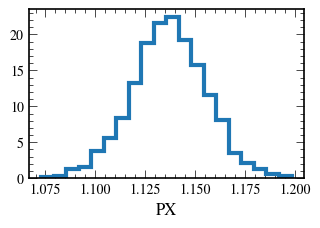

In [39]:
plt.hist(samps['p0_PX'], **hist_settings)
plt.xlabel('PX')
plt.show()

## White Noise

In [50]:
wn = m.make_white_noise(stabilize_TNT = True) # stabilize_TNT is a MUST if you are doing single precision
wn_lower_bound, wn_upper_bound = wn.get_prior_bounds()

  0%|          | 0/1 [00:00<?, ?it/s]

Constructing the white noise cov matrix for B1855+09: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]


## Red Noise

In [48]:
basis_string = "unc"

## Understanding `basis_string`

The `basis_string` is a compact way to tell the software **how different signals should be organized into basis matrices**.

The general form is:

    [timing model] | [signals sharing a basis] -> [basis to use] ; [separate signals]

Each part is optional depending on the desired configuration.

### 1. Signals can have separate bases

Suppose your model contains signals named `unc`, `cor`, `dm`, and `cw`.

Signals listed after `;` are treated as **separate bases**.

For example:

    unc ; cor

means that `unc` and `cor` are all treated separately. There is no shared basis in this example.

### 2. Signals can share a basis

The syntax

    unc+cor->unc

means:

> `unc` and `cor` share one basis, and the basis associated with `unc` is used as the representative basis.

Breaking this down:

    unc + cor -> unc
     │     │       │
     │     │       └── use unc's basis
     │     └────────── cor belongs to the shared group
     └──────────────── unc belongs to the shared group

The signal after `->` must be one of the signals listed before the arrow.

For example,

    unc+cor->cor

means that `unc` and `cor` still share a basis, but now `cor` provides the representative basis.

****NOTE****: signals sharing bases does not mean same number of frequencies. It means that one basis contains the other.

### 3. Adding the timing-model basis

Putting

    ltm|

at the beginning tells the software to also include the pulsar's **linear timing-model basis (M-matrix)**.

For example,

    unc+cor->unc

does **not** include the timing-model basis, while

    ltm|unc+cor->unc

uses the same shared basis configuration **and** includes the timing-model M-matrix.


### 4. Combining shared and separate bases

A more complete example is:

    ltm|unc+cor->unc ; cw

Read this from left to right as:

1. `ltm|` — include the linear timing-model M-matrix.
2. `unc+cor` — `unc` and `cor` belong to a shared basis group.
3. `->unc` — use `unc` as the representative basis for that group.
4. `; cw` — keep `cw` as a separate basis.

Conceptually:

    ltm | unc + cor -> unc ; cw
     │      │    │      │     │
     │      └────┴──────┘     └── separate basis
     │       shared basis
     │       represented by unc
     │
     └── include timing-model M-matrix

### Examples

| `basis_string` | Meaning |
|---|---|
| `unc+cor->unc` | `unc` and `cor` share a basis; use `unc`'s basis |
| `ltm\|unc+cor->unc` | Same as above, plus the timing-model M-matrix |
| `ltm\|unc+cor->unc ; cw` | Timing model + shared `unc/cor` basis + separate `cw` basis |
| `unc ; cor,dm` | `unc`, `cor`, and `dm` all have separate bases |
| `ltm\|unc ; cor,dm` | Same as above, plus the timing-model M-matrix |

### Quick reference

- `ltm|` → include the linear timing-model (M-matrix) basis
- `+` → signals belong to the same shared basis
- `->` → choose which signal provides the representative basis
- `;` → separate the shared/main group from signals with independent bases
- `,` → separate multiple independent signals

For example:

    ltm|unc+cor->unc ; cw,dm

means:

> Include the timing-model M-matrix; let `unc` and `cor` share the basis provided by `unc`; and keep `cw` and `dm` as separate bases.

In [49]:
rn = m.make_red_noise(basis_string,
                use_pulsar_tspan = False, #should non-gwb pulsar noise have Tpsan based on each individual pulsar?
                irn_psd_function = partial(powerlaw), # PSD function
                gwb_psd_function = partial(powerlaw, gamma = 13/3), #PSD function
                orf_function = bin_orf, #ORF function
                dm_psd_function = None, #PSD function for chromatic noise

                irn_lower_bound_psd = jnp.array([-18, 0.]), #the order must match what is accepted by the PSD function
                irn_upper_bound_psd = jnp.array([-11, 7.]), #the order must match what is accepted by the PSD function
                dm_lower_bound_psd = None, #the order must match what is accepted by the PSD function
                dm_upper_bound_psd = None, #the order must match what is accepted by the PSD function
                gwb_lower_bound_psd = jnp.array([-18]), #the order must match what is accepted by the PSD function
                gwb_upper_bound_psd = jnp.array([-11]), #the order must match what is accepted by the PSD function
                lower_bound_orf = jnp.ones(7) * -.95, #the order must match what is accepted by the PSD function
                upper_bound_orf = jnp.ones(7) * .95, #the order must match what is accepted by the PSD function
                 )

In [ ]:
helpers = rn.get_helpers(reff = jnp.concat(data.raw_residuals), #reff is the effective residuals. It can be the actual `true` residuals
                                                                # or be model-subtracted residuals for Block Gibbs sampling
                white_noise_params = wn.prior_draw() #some random draw from white noise prior
                )

In [55]:
## This is TNT: helpers[0]
## This is TNr: helpers[1]
## This is rNr: helpers[2]
## This is logdetN: helpers[3]

### Let's sample all together!

In [ ]:
### method 1: ATLAS Model Maker

In [57]:
model_maker?

Signature:
model_maker(
    raw_residuals,
    super_sig,
    marg_over_non_gwb,
    vary_white=False,
    wn_lower_bound=None,
    wn_upper_bound=None,
    tm_model=None,
    helpers=None,
    save_red_coeff=False,
    fixed_white_noise_params=None,
    red_noise_basis=None,
    tm_direct_sampling_type='klam',
)
Docstring:
NumPyro model for the ATLAS global fit.

The function is the NumPyro model: call it via ``MCMC(model_maker, ...)``,
passing keyword arguments through ``MCMC.run``.  NumPyro traces through it
to build the joint density; do not call it directly.

Parameters
----------
raw_residuals : list of array
    Per-pulsar timing residuals in seconds, ``[npsr][n_toa_p]``.  Used as
    the stochastic residuals when no timing model is sampled (``tm_model``
    is None).
super_sig : SuperSignal
    The assembled signal (T-matrix + phi model + likelihood helpers).
marg_over_non_gwb : bool
    When True, the non-GWB coefficients (timing, IRN, DM, GTM) are
    marginalised analyticall

In [60]:
nuts_kernel = NUTS(
            model = model_maker,
            target_accept_prob = 0.8,
            max_tree_depth = 10)
mcmc = MCMC(
    sampler=nuts_kernel,
    num_warmup=500,
    num_samples=3000,
    num_chains=1,
)
mcmc.run(jrandom.key(170817), 
                extra_fields=("~z.z_a",), #no need to save the auxilary coefficients
                raw_residuals = jnp.concat(data.raw_residuals), # the true residuals
                super_sig = rn, #the signal with the liklelihood calls
                vary_white = True,
                wn_lower_bound = wn_lower_bound, #prior for white noise
                wn_upper_bound = wn_upper_bound, #prior for white noise
                tm_model = tm, #timing model
                helpers = helpers,
                save_red_coeff = False, #do you want to save the coefficients
                marg_over_non_gwb = False)

sample: 100%|██████████| 3500/3500 [15:46<00:00,  3.70it/s, 127 steps of size 4.37e-02. acc. prob=0.86]  


In [62]:
samps = mcmc.get_samples()

In [71]:
z_post = samps['timing_k'] * samps['timing_lam'][:, None]
results = jax.vmap(lambda z: tm.z_to_theta(0, z))(z_post)
results['PX']

Array([0.7854556 , 0.7283699 , 0.74514041, ..., 0.48385617, 0.72973263,
       0.71829506], dtype=float64)

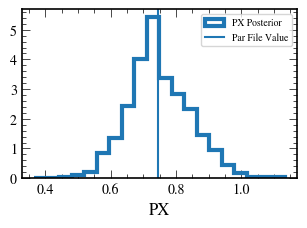

In [78]:
plt.hist(results['PX'], **hist_settings, label = 'PX Posterior')
plt.axvline(tm.aux_list[0]['theta_0']['PX'], label = 'Par File Value')
plt.xlabel('PX')
plt.legend()
plt.show()

In [ ]:
# Method 2:Block Gibbs (example of a three block system. you can have more or less!)

In [ ]:
three_block_kernel = BlockGibbs(
        [
        nuts_kernel, #first block (Timing)
        nuts_kernel, #second block (White Noise)
        nuts_kernel #third block (Red Noise)
        ],
        
        [
        ['timing_k', 'timing_lam'], #the params of the first block
        ['white_noise'], #the params of the second block
        ['red_noise', 'z_a'] #the params of the third block (NOTE: `z_a`, which is an auxillary coefficeint, must be in the red noise model, always!)
        ]
    )

mcmc = MCMC(
    sampler=three_block_kernel,
    num_warmup=500,
    num_samples=3000,
    num_chains=1,
)
mcmc.run(jrandom.key(170817),
                extra_fields=("~z.z_a",), #no need to save the auxilary coefficients 
                raw_residuals = jnp.concat(data.raw_residuals), # the true residuals
                super_sig = rn, #the signal with the liklelihood calls
                vary_white = True,
                wn_lower_bound = wn_lower_bound, #prior for white noise
                wn_upper_bound = wn_upper_bound, #prior for white noise
                tm_model = tm, #timing model
                helpers = helpers,
                save_red_coeff = False, #do you want to save the coefficients
                marg_over_non_gwb = False)

sample: 100%|██████████| 3500/3500 [11:28<00:00,  5.09it/s, 7/31/7 steps of size 1.28e-01/1.18e-01/5.04e-01. acc. prob=0.88/0.91/0.85]   


In [86]:
samps_block_gibbs = mcmc.get_samples()

In [87]:
z_post_block_gibbs  = samps_block_gibbs ['timing_k'] * samps_block_gibbs ['timing_lam'][:, None]
results_block_gibbs  = jax.vmap(lambda z: tm.z_to_theta(0, z))(z_post_block_gibbs)
results_block_gibbs ['PX']

Array([0.81591811, 0.74765431, 0.74800698, ..., 0.93918556, 0.81434223,
       0.87684036], dtype=float64)

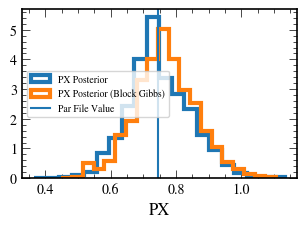

In [89]:
plt.hist(results['PX'], **hist_settings, label = 'PX Posterior')
plt.hist(results_block_gibbs['PX'], **hist_settings, label = 'PX Posterior (Block Gibbs)')
plt.axvline(tm.aux_list[0]['theta_0']['PX'], label = 'Par File Value')
plt.xlabel('PX')
plt.legend()
plt.show()